# Handling at constant steer

Step 5.7. Steering fixed, speed in steps of 0.3 / 0.5 / 0.7 / 0.9 / 1.1 / 1.3 m/s,
6 s each, one continuous run (`drive_steps.py`). Slicks on tiles, LiPo nearly
full, 2026-09-24.

The plan was lateral acceleration from the accelerometer mean, which does not
depend on the slipping wheels. It does not work: while driving, the lateral
accelerometer has 1-4 m/s^2 of std, spikes up to 18 m/s^2 (tile joints), and
noise correlated over ~0.1 s, so a 4 s mean moves by up to 2 m/s^2. Below is
what the gyro and the wheels say on their own; a_y and mu wait for an external
position measurement.

In [1]:
import sys
sys.path.append('../scripts')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import bagtools as bt

L = 0.173
R_WHEEL = 0.0299
DELTA = {0.30: 17.83, 0.52: 27.43}      # steering map, kinematic_model.ipynb
STEPS = [0.3, 0.5, 0.7, 0.9, 1.1, 1.3]


def split_runs(drive):
    t = drive['t'].values
    gaps = np.flatnonzero(np.diff(t) > 2.0)
    return np.r_[t[0], t[gaps + 1]]


# (bag, run): handling run 0 hit the cushions, run 2 did not fit the space
runs = [('handling', 1), ('handling_b', 0)]

rows, series = [], {}
for bag, i in runs:
    d = bt.zero_time(bt.load(f'../data/{bag}_parquet'))
    js, drive, imu = d['joint_states'], d['drive'], d['imu_data_raw']
    starts = split_runs(drive)
    t0 = starts[i]
    bias = bt.window(imu, 0, starts[0] - 0.5)['gz'].median()    # at rest before the first run
    steer = round(bt.window(drive, t0 + 2, t0 + 3)['cmd_steer'].mean(), 2)
    tan_d = np.tan(np.radians(DELTA[steer]))
    series[steer] = (t0, js, imu, bias, tan_d)
    for k, cmd in enumerate(STEPS):
        a = t0 + 2 + k * 7 + 2          # skip ramp and first 2 s of each hold
        r = bt.window(imu, a, a + 4)['gz'].mean() - bias
        w = bt.window(js, a, a + 4)
        v = R_WHEEL * (w['wl'] + w['wr']).mean() / 2
        rows.append({'steer': steer, 'cmd [m/s]': cmd, 'v wheels [m/s]': v,
                     'r [rad/s]': r, 'r / r_kin': r / (v * tan_d / L)})

steps = pd.DataFrame(rows).round(3)
steps

/home/pietro/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


,steer,cmd [m/s],v wheels [m/s],r [rad/s],r / r_kin
0,0.30,0.3,0.301,0.480,0.858
1,0.30,0.5,0.501,0.793,0.852
2,0.30,0.7,0.701,1.083,0.831
3,0.30,0.9,0.901,1.374,0.821
4,0.30,1.1,1.101,1.558,0.761
5,0.30,1.3,1.175,1.518,0.695
6,0.52,0.3,0.301,0.785,0.871
7,0.52,0.5,0.500,1.298,0.865
8,0.52,0.7,0.700,1.776,0.845
9,0.52,0.9,0.900,2.230,0.826


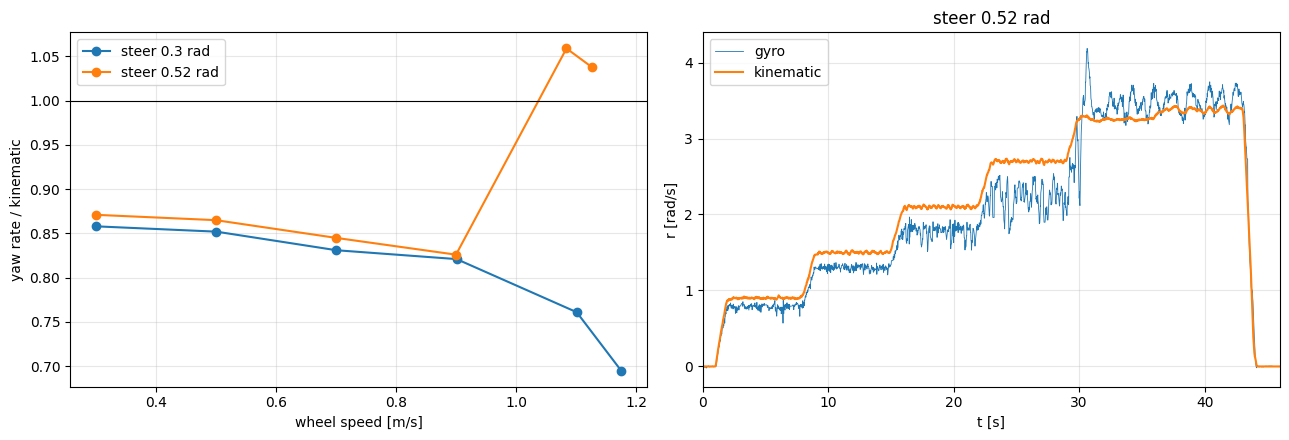

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for steer, g in steps.groupby('steer'):
    ax[0].plot(g['v wheels [m/s]'], g['r / r_kin'], 'o-', label=f'steer {steer} rad')
ax[0].axhline(1, color='k', lw=0.8)
ax[0].set_xlabel('wheel speed [m/s]')
ax[0].set_ylabel('yaw rate / kinematic')
ax[0].grid(alpha=0.3)
ax[0].legend()

t0, js, imu, bias, tan_d = series[0.52]
ax[1].plot(imu['t'] - t0, imu['gz'] - bias, lw=0.6, label='gyro')
ax[1].plot(js['t'] - t0, R_WHEEL * (js['wl'] + js['wr']) / 2 * tan_d / L, label='kinematic')
ax[1].set_xlim(0, 46)
ax[1].set_xlabel('t [s]')
ax[1].set_ylabel('r [rad/s]')
ax[1].set_title('steer 0.52 rad')
ax[1].grid(alpha=0.3)
ax[1].legend()
plt.tight_layout()
plt.show()

At 0.30 rad the yaw rate falls behind the kinematic one as speed grows, from
0.86 to 0.70 of it: the car runs wide. At full lock it stays at 0.83-0.87 up to
0.9 m/s, then between 0.9 and 1.1 m/s the rear lets go and the yaw rate jumps
above the kinematic value (1.06). From there the car holds a **steady drift at
~3.5 rad/s** with the motors at free speed, and stays in place.

The ratio below 1 is the spool (step 5.5). Above 1 the car turns tighter than
the geometry allows while the wheels spin faster than it moves, so neither the
radius nor the speed can be read from the wheels.

## Overhead video

Phone 2 m above the floor, pointing down. Two paper markers on the center line of
the car, pink 47 mm behind the rear axle and green 220 mm ahead of it, 267 mm
apart; their distance in each frame gives the scale. `track_markers.py` finds
them by color. Video and bag are aligned on the start of motion. Positions of
the rear axle and of the CG follow from the two markers, velocities from a
central difference over +-0.1 s, sideslip is the angle between velocity and
heading.

In [3]:
G = 9.81
D_MARK = 0.267        # m between marker centers
PINK_BEHIND = 0.047   # m, pink marker behind the rear axle
LR = 0.0744           # m, CG ahead of the rear axle (inertia.ipynb)


def load_track(path):
    m = pd.read_parquet(path)
    d = np.hypot(m['green_x'] - m['pink_x'], m['green_y'] - m['pink_y'])
    scale = D_MARK / d.median()                                 # m per px at marker height
    m['valid'] = (d - d.median()).abs() < 0.05 * d.median()     # both markers, none clipped
    ux = (m['green_x'] - m['pink_x']) / d
    uy = -(m['green_y'] - m['pink_y']) / d                       # image y points down
    m['rear_x'] = m['pink_x'] * scale + PINK_BEHIND * ux
    m['rear_y'] = -m['pink_y'] * scale + PINK_BEHIND * uy
    m['cg_x'], m['cg_y'] = m['rear_x'] + LR * ux, m['rear_y'] + LR * uy
    m['psi'] = np.arctan2(uy, ux)

    dt = m['t'].diff().median()
    k = round(0.1 / dt)
    m['ok'] = m['valid'] & m['valid'].shift(k, fill_value=False) & m['valid'].shift(-k, fill_value=False)
    for p in ['rear', 'cg']:
        vx = (m[p + '_x'].shift(-k) - m[p + '_x'].shift(k)) / (2 * k * dt)
        vy = (m[p + '_y'].shift(-k) - m[p + '_y'].shift(k)) / (2 * k * dt)
        m['v_' + p] = np.hypot(vx, vy)
        m['beta_' + p] = np.degrees(np.angle(np.exp(1j * (np.arctan2(vy, vx) - m['psi']))))
    return m


def offset(m, js):
    # bag time minus video time, from the first motion in each
    first = m.index[m['valid']][0]
    moved = m['valid'] & (np.hypot(m['rear_x'] - m.at[first, 'rear_x'],
                                   m['rear_y'] - m.at[first, 'rear_y']) > 0.005)
    return js.loc[(js['wl'] + js['wr']) / 2 > 0.3, 't'].iloc[0] - m.loc[moved, 't'].iloc[0]


def window_stats(m, js, imu, bias, t0, t1, off):
    # t0, t1 in bag time
    w = m[(m['t'] >= t0 - off) & (m['t'] < t1 - off) & m['ok']]
    r = bt.window(imu, t0, t1)['gz'].mean() - bias
    v_wheels = R_WHEEL * bt.window(js, t0, t1)[['wl', 'wr']].mean().mean()
    return {'v wheels': v_wheels, 'v cg': w['v_cg'].mean(), 'r gyro': r,
            'r video': np.polyfit(w['t'], np.unwrap(w['psi']), 1)[0],
            'R cg': w['v_cg'].mean() / r, 'R rear': w['v_rear'].mean() / r,
            'a_y [g]': w['v_cg'].mean() * r / G,
            'beta cg': w['beta_cg'].mean(), 'beta rear': w['beta_rear'].mean(),
            'v rear / v wheels': w['v_rear'].mean() / v_wheels}


def load_run(name):
    d = bt.zero_time(bt.load(f'../data/{name}_parquet'))
    m = load_track(f'../data/video/{name}_markers.parquet')
    t_cmd = d['drive']['t'].iloc[0]
    bias = bt.window(d['imu_data_raw'], 0, t_cmd - 0.5)['gz'].median()
    return m, d['joint_states'], d['imu_data_raw'], bias, t_cmd, offset(m, d['joint_states'])

### Check: slow circle at full lock

0.3 m/s, phone video sent compressed (464x848, 30 fps). Known from step 5.5: rear
axle radius 325 mm by tape, car at 85% of wheel speed, no sideslip at the rear
axle at this speed.

In [4]:
m, js, imu, bias, t_cmd, off = load_run('video_cal')
cal = window_stats(m, js, imu, bias, t_cmd + 4, t_cmd + 16, off)
print(f"offset video -> bag {off:.2f} s, valid frames {100 * m['valid'].mean():.0f} %")
pd.Series(cal).round(3)

offset video -> bag 7.68 s, valid frames 100 %


v wheels              0.300
v cg                  0.249
r gyro                0.777
r video               0.785
R cg                  0.321
R rear                0.312
a_y [g]               0.020
beta cg              13.903
beta rear             0.377
v rear / v wheels     0.807
dtype: float64

Video and gyro agree on yaw rate within 1%, and the rear axle shows no sideslip,
as the kinematics require. Radius 312 mm against 325 by tape on another day, speed
ratio 0.81 against 0.85: within what tape and a wandering circle allow.

### Speed steps at full lock

Original 1080p, 60 fps. Last 4 s of each 6 s step.

In [5]:
m, js, imu, bias, t_cmd, off = load_run('video_drift')
rows = []
for k, cmd in enumerate(STEPS):
    t0 = t_cmd + 2 + 7 * k + 2
    rows.append({'cmd': cmd, **window_stats(m, js, imu, bias, t0, t0 + 4, off)})
drift = pd.DataFrame(rows).round(3)
print(f"offset video -> bag {off:.2f} s, valid frames {100 * m['valid'].mean():.0f} %")
drift

offset video -> bag 1.54 s, valid frames 96 %


,cmd,v wheels,v cg,r gyro,r video,R cg,R rear,a_y [g],beta cg,beta rear,v rear / v wheels
0,0.3,0.300,0.251,0.768,0.779,0.327,0.318,0.020,13.561,0.180,0.813
1,0.5,0.500,0.414,1.284,1.295,0.323,0.314,0.054,13.442,-0.033,0.806
2,0.7,0.701,0.581,1.764,1.756,0.329,0.321,0.104,12.870,-0.240,0.808
3,0.9,0.900,0.743,2.178,2.175,0.341,0.336,0.165,10.444,-2.152,0.812
4,1.1,1.090,0.484,3.508,3.557,0.138,0.178,0.173,-20.678,-43.436,0.572
5,1.3,1.125,0.488,3.535,3.560,0.138,0.177,0.176,-19.372,-42.470,0.555


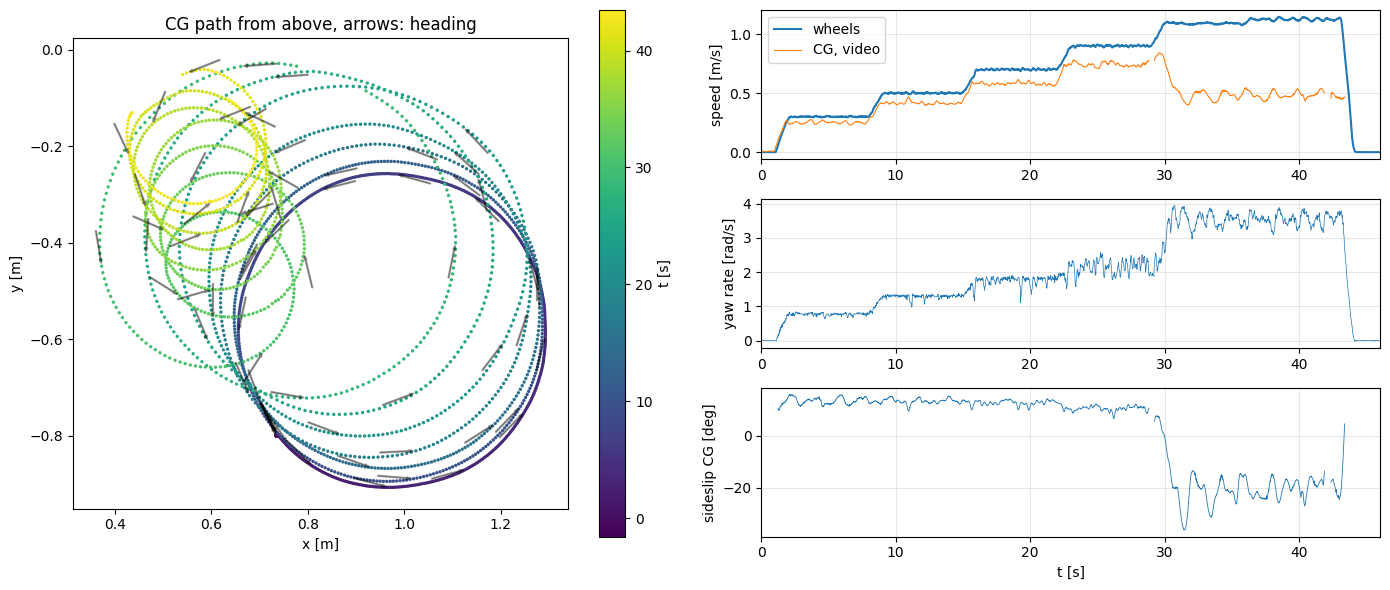

In [6]:
fig = plt.figure(figsize=(14, 6))
ax0 = fig.add_subplot(1, 2, 1)
ax1, ax2, ax3 = [fig.add_subplot(3, 2, k) for k in (2, 4, 6)]

w = m[m['valid']]
sc = ax0.scatter(w['cg_x'], w['cg_y'], c=w['t'] + off - t_cmd, s=2, cmap='viridis')
for i in range(0, len(w), 40):
    row = w.iloc[i]
    ax0.arrow(row['rear_x'], row['rear_y'], 0.06 * np.cos(row['psi']), 0.06 * np.sin(row['psi']),
              width=0.002, color='k', alpha=0.35)
ax0.set_aspect('equal')
ax0.set_xlabel('x [m]')
ax0.set_ylabel('y [m]')
ax0.set_title('CG path from above, arrows: heading')
fig.colorbar(sc, ax=ax0, label='t [s]')

t_run = m['t'] + off - t_cmd
moving = m['ok'] & (m['v_cg'] > 0.1)
ax1.plot(js['t'] - t_cmd, R_WHEEL * (js['wl'] + js['wr']) / 2, label='wheels')
ax1.plot(t_run, m['v_cg'].where(m['ok']), lw=0.8, label='CG, video')
ax1.set_ylabel('speed [m/s]')
ax1.legend(loc='upper left')
ax2.plot(imu['t'] - t_cmd, imu['gz'] - bias, lw=0.5)
ax2.set_ylabel('yaw rate [rad/s]')
ax3.plot(t_run, m['beta_cg'].where(moving), lw=0.6)
ax3.set_ylabel('sideslip CG [deg]')
ax3.set_xlabel('t [s]')
for a in (ax1, ax2, ax3):
    a.set_xlim(0, 46)
    a.grid(alpha=0.3)
plt.tight_layout()
fig.savefig('../media/drift_topview.png', dpi=120)
plt.show()

### Handling diagram

Steady state, $\delta = L/R + K_{us}\,a_y/g$. With $\delta$ fixed at full lock
(27.4 deg from the steering map) and $R$ at the rear axle from the video, the
slope of $\delta - L/R$ against $a_y/g$ is the understeer gradient.

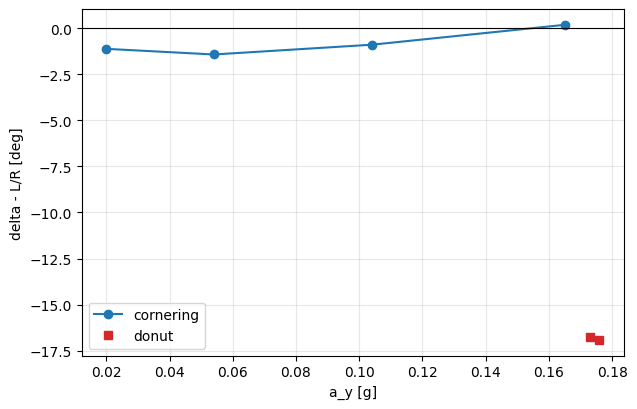

K_us = +9.8 deg/g over 0.02-0.17 g


In [7]:
delta = DELTA[0.52]
drift['delta - L/R [deg]'] = delta - np.degrees(np.arctan(L / drift['R rear']))
lin = drift[drift['beta rear'] > -10]               # before the rear lets go
K_us = np.polyfit(lin['a_y [g]'], lin['delta - L/R [deg]'], 1)[0]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(lin['a_y [g]'], lin['delta - L/R [deg]'], 'o-', label='cornering')
ax.plot(drift.loc[drift['beta rear'] <= -10, 'a_y [g]'], drift.loc[drift['beta rear'] <= -10, 'delta - L/R [deg]'],
        's', color='C3', label='donut')
ax.axhline(0, color='k', lw=0.8)
ax.set_xlabel('a_y [g]')
ax.set_ylabel('delta - L/R [deg]')
ax.grid(alpha=0.3)
ax.legend()
plt.show()
print(f"K_us = {K_us:+.1f} deg/g over {lin['a_y [g]'].min():.2f}-{lin['a_y [g]'].max():.2f} g")

Four points over 0.15 g: slightly understeering, about +10 deg/g, with a 1 deg
offset that is the size of the steering map error. Then the diagram jumps to the
donut, 16 deg below the line: the car turns much tighter than the steering asks.

### Two frames

Overlay from `overlay_video.py`: CG path of the last 1.5 s, heading (white) and
velocity (orange) at the CG.

In [8]:
import cv2

cap = cv2.VideoCapture('../data/video/video_drift_overlay.mp4')
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for a, t_rel in zip(ax, [20.0, 38.0]):
    i = int(np.argmin(np.abs(m['t'] + off - t_cmd - t_rel)))
    cap.set(cv2.CAP_PROP_POS_FRAMES, i)
    ok, frame = cap.read()
    cx = int((m.at[i, 'pink_x'] + m.at[i, 'green_x']) / 2)
    cy = int((m.at[i, 'pink_y'] + m.at[i, 'green_y']) / 2)
    x0 = min(max(cx - 350, 0), frame.shape[1] - 700)
    y0 = min(max(cy - 250, 0), frame.shape[0] - 500)
    a.imshow(cv2.cvtColor(frame[y0:y0 + 500, x0:x0 + 700], cv2.COLOR_BGR2RGB))
    a.set_title(f"t = {t_rel:.0f} s: {m.at[i, 'v_cg']:.2f} m/s, sideslip {m.at[i, 'beta_cg']:+.0f} deg")
    a.axis('off')
plt.tight_layout()
fig.savefig('../media/drift_frames.jpg', dpi=100)
plt.close(fig)

![two frames](../media/drift_frames.jpg)

Up to 0.9 m/s the car circles at 81% of wheel speed, the rear axle radius grows
slightly (318 -> 336 mm) and the CG sideslip is the kinematic +13.6 deg
(atan(lr/R)), down to +10 at 0.9 m/s. The largest lateral acceleration before the rear lets go is
**0.17 g**.

Then the rear breaks away and the car settles into a **donut**: CG speed 0.49 m/s
while the wheels turn at 1.1 m/s, yaw rate 3.5 rad/s, CG radius 14 cm, sideslip
**-20 deg at the CG and -43 deg at the rear axle**, and only 0.17 g of lateral
acceleration. It holds with the steering at full lock and the motors at free
speed, without any control.

Friction is not measurable from this test: in the donut most of the rear grip
goes into wheelspin, not cornering. The 0.32-0.37 read in `envelope.ipynb` from
the same maneuver assumed the car was on the geometric circle; it was in this
donut. A straight full-throttle launch with wheelspin gives mu directly
(a_x = mu g times the rear axle load share).

## Friction: straight launch

The donut cannot give friction, so a direct test: from rest, speed setpoint
stepped to 1.3 m/s (`step_input.py`), steering straight, three runs filmed from
above. The rear wheels spin up far faster than the car can follow, so the rear
tires slide and push with kinetic friction. With the load transfer of the
acceleration on the rear axle:

$$m a_x = \mu N_r, \qquad N_r = m g\frac{l_f}{L} + m a_x\frac{h}{L}
\quad\Rightarrow\quad \mu = \frac{a_x}{g\,l_f/L + a_x h/L}$$

$a_x$ from a parabola on the distance travelled by the CG, 0.05-0.5 s after the
wheels start.

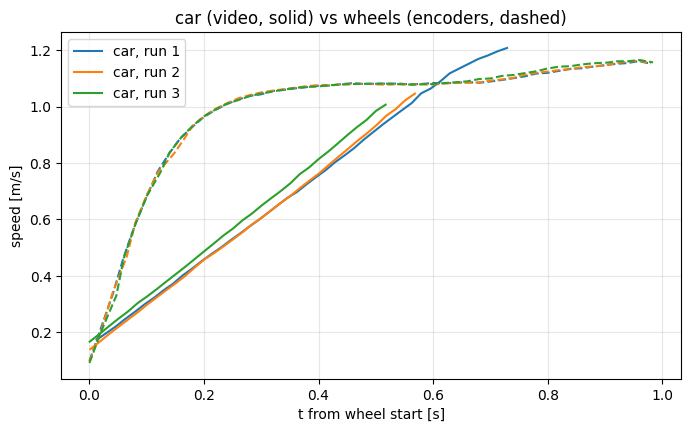

mu = 0.248 +- 0.010


,a_x [m/s^2],mu
0,1.481,0.240
1,1.507,0.244
2,1.611,0.259


In [9]:
LF, H = 0.0986, 0.067          # inertia.ipynb

m = load_track('../data/video/launch_markers.parquet')
js = bt.zero_time(bt.load('../data/launch_parquet'))['joint_states']
off = offset(m, js)
v_wheels = R_WHEEL * (js['wl'] + js['wr']) / 2
starts = js['t'][(v_wheels > 0.05) & (v_wheels.shift() <= 0.05)].to_numpy()

rows = []
fig, ax = plt.subplots(figsize=(8, 4.5))
for k, tb in enumerate(starts):
    w = m[(m['t'] >= tb - off) & (m['t'] <= tb - off + 0.5) & m['valid']]
    t = w['t'].to_numpy() - (tb - off)
    dist = np.hypot(w['cg_x'] - w['cg_x'].iloc[0], w['cg_y'] - w['cg_y'].iloc[0]).to_numpy()
    fit = t >= 0.05
    a = 2 * np.polyfit(t[fit], dist[fit], 2)[0]
    rows.append({'a_x [m/s^2]': a, 'mu': a / (G * LF / L + a * H / L)})

    wv = m[(m['t'] >= tb - off) & (m['t'] <= tb - off + 1.0) & m['ok']]
    ax.plot(wv['t'] - (tb - off), wv['v_cg'], color=f'C{k}', label=f'car, run {k + 1}')
    wb = bt.window(js, tb, tb + 1.0)
    ax.plot(wb['t'] - tb, R_WHEEL * (wb['wl'] + wb['wr']) / 2, '--', color=f'C{k}')
ax.set_xlabel('t from wheel start [s]')
ax.set_ylabel('speed [m/s]')
ax.set_title('car (video, solid) vs wheels (encoders, dashed)')
ax.grid(alpha=0.3)
ax.legend()
plt.show()

launch = pd.DataFrame(rows).round(3)
print(f"mu = {launch['mu'].mean():.3f} +- {launch['mu'].std():.3f}")
launch

The wheels reach 1 m/s in 0.3 s, the car takes 0.6 s and accelerates at a
constant rate until it catches up: sliding at constant friction, parabola
residual 0.2 mm. **mu = 0.25 +- 0.01** for the slicks on tiles, the kinetic value,
the one the rear sees in a drift. Peak friction at small slip can be higher and
is not measured here.

With 0.25, full lock on the geometric circle would allow 0.25 g; the rear lets go
at 0.17 g, likely because the spool already spends part of the rear grip on
scrub.